# Chromosome IV Replicate 1 - Prototype Replication Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs


In [3]:
config, _ = load_default_chrom_configs()
config.shift_parameters_for_alpha()

real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1, chr=4)

Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0


In [4]:
real_deconv1.config.params_dic

{'mu0': -4.790099999999999,
 'delta': 8.1805,
 'sigma0': 10.9885,
 'sigmav': 0.1424,
 'lambda': 68.1914,
 'gamma1': 0.32672132761609235,
 'gamma2': 0.5773213276160923,
 'halted': 0.2245,
 'alpha': 22}

In [5]:
real_deconv1.setup_deconvolution(real_deconv1.config)
real_deconv1.iterative_deconvolution_updates(1)

Initializing N using config H.
Initializing B using timepoint 0
Iteration 0
0/705 - 00:00:00.025
100/705 - 00:00:00.081
200/705 - 00:00:00.160
300/705 - 00:00:00.215
400/705 - 00:00:00.305
500/705 - 00:00:00.351
600/705 - 00:00:00.406
700/705 - 00:00:00.446
Iteration completed 00:00:01.322, rn=0.0063539314832201325


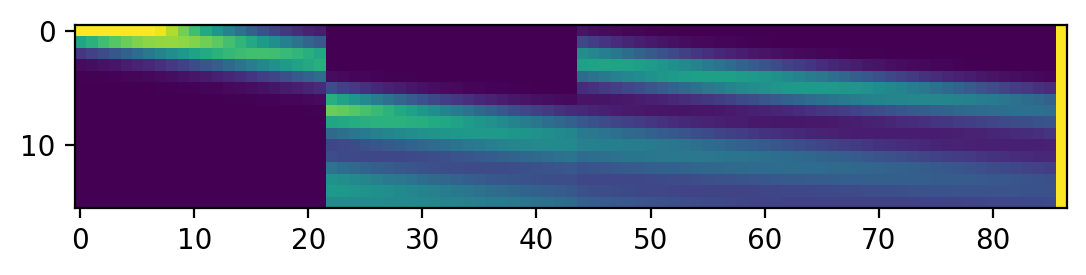

In [6]:
plt.imshow(real_deconv1.config.H, vmax=0.05)

In [7]:
from src.optimize_H import ParameterOptimizer

In [8]:
timepoints = config.timepoints
initial_values = config.params_dic

init_params_df = pd.DataFrame(initial_values, index=['value']).T
init_params_df = init_params_df.drop('alpha')
init_params_df

,value
mu0,-4.790100
delta,8.180500
sigma0,10.988500
sigmav,0.142400
lambda,68.191400
gamma1,0.326721
gamma2,0.577321
halted,0.224500


In [16]:
bounds_dic = {
    'mu0': (-30, 30),
    'lambda': (40, 80),
    'delta': (0, 24),
    'sigma0': (1, 14),
    'sigmav': (0.01, 1.),
    'gamma1': (0., 1.),
    'gamma2': (0., 1.),
    'halted': (0.0, 1.),
}

bounds_params_df = pd.DataFrame(bounds_dic, index=['min', 'max']).T
params_df = init_params_df.join(bounds_params_df)
params_df


,value,min,max
mu0,-4.790100,-30.00,30.0
delta,8.180500,0.00,24.0
sigma0,10.988500,1.00,14.0
sigmav,0.142400,0.01,1.0
lambda,68.191400,60.00,80.0
gamma1,0.326721,0.00,1.0
gamma2,0.577321,0.00,1.0
halted,0.224500,0.00,1.0


In [17]:
real_deconv1.setup_deconvolution(real_deconv1.config)

Initializing N using config H.
Initializing B using timepoint 0


In [18]:
real_deconv1.iterative_deconvolution_updates(20)

Iteration 0
0/705 - 00:00:00.010
100/705 - 00:00:00.109
200/705 - 00:00:00.198
300/705 - 00:00:00.285
400/705 - 00:00:00.375
500/705 - 00:00:00.467
600/705 - 00:00:00.559
700/705 - 00:00:00.647
Iteration completed 00:00:00.992, rn=0.00606202198660376
Iteration 1
0/705 - 00:00:00.993
100/705 - 00:00:01.096
200/705 - 00:00:01.187
300/705 - 00:00:01.283
400/705 - 00:00:01.367
500/705 - 00:00:01.454
600/705 - 00:00:01.544
700/705 - 00:00:01.641
Iteration completed 00:00:02.282, rn=0.0032953761924009667
Iteration 2
0/705 - 00:00:02.286
100/705 - 00:00:02.403
200/705 - 00:00:02.510
300/705 - 00:00:02.623
400/705 - 00:00:02.725
500/705 - 00:00:02.813
600/705 - 00:00:02.899
700/705 - 00:00:02.995
Iteration completed 00:00:03.512, rn=0.0027663324297134352
Iteration 3
0/705 - 00:00:03.534
100/705 - 00:00:03.638
200/705 - 00:00:03.741
300/705 - 00:00:03.854
400/705 - 00:00:03.943
500/705 - 00:00:04.029
600/705 - 00:00:04.114
700/705 - 00:00:04.199
Iteration completed 00:00:05.123, rn=0.0026606597

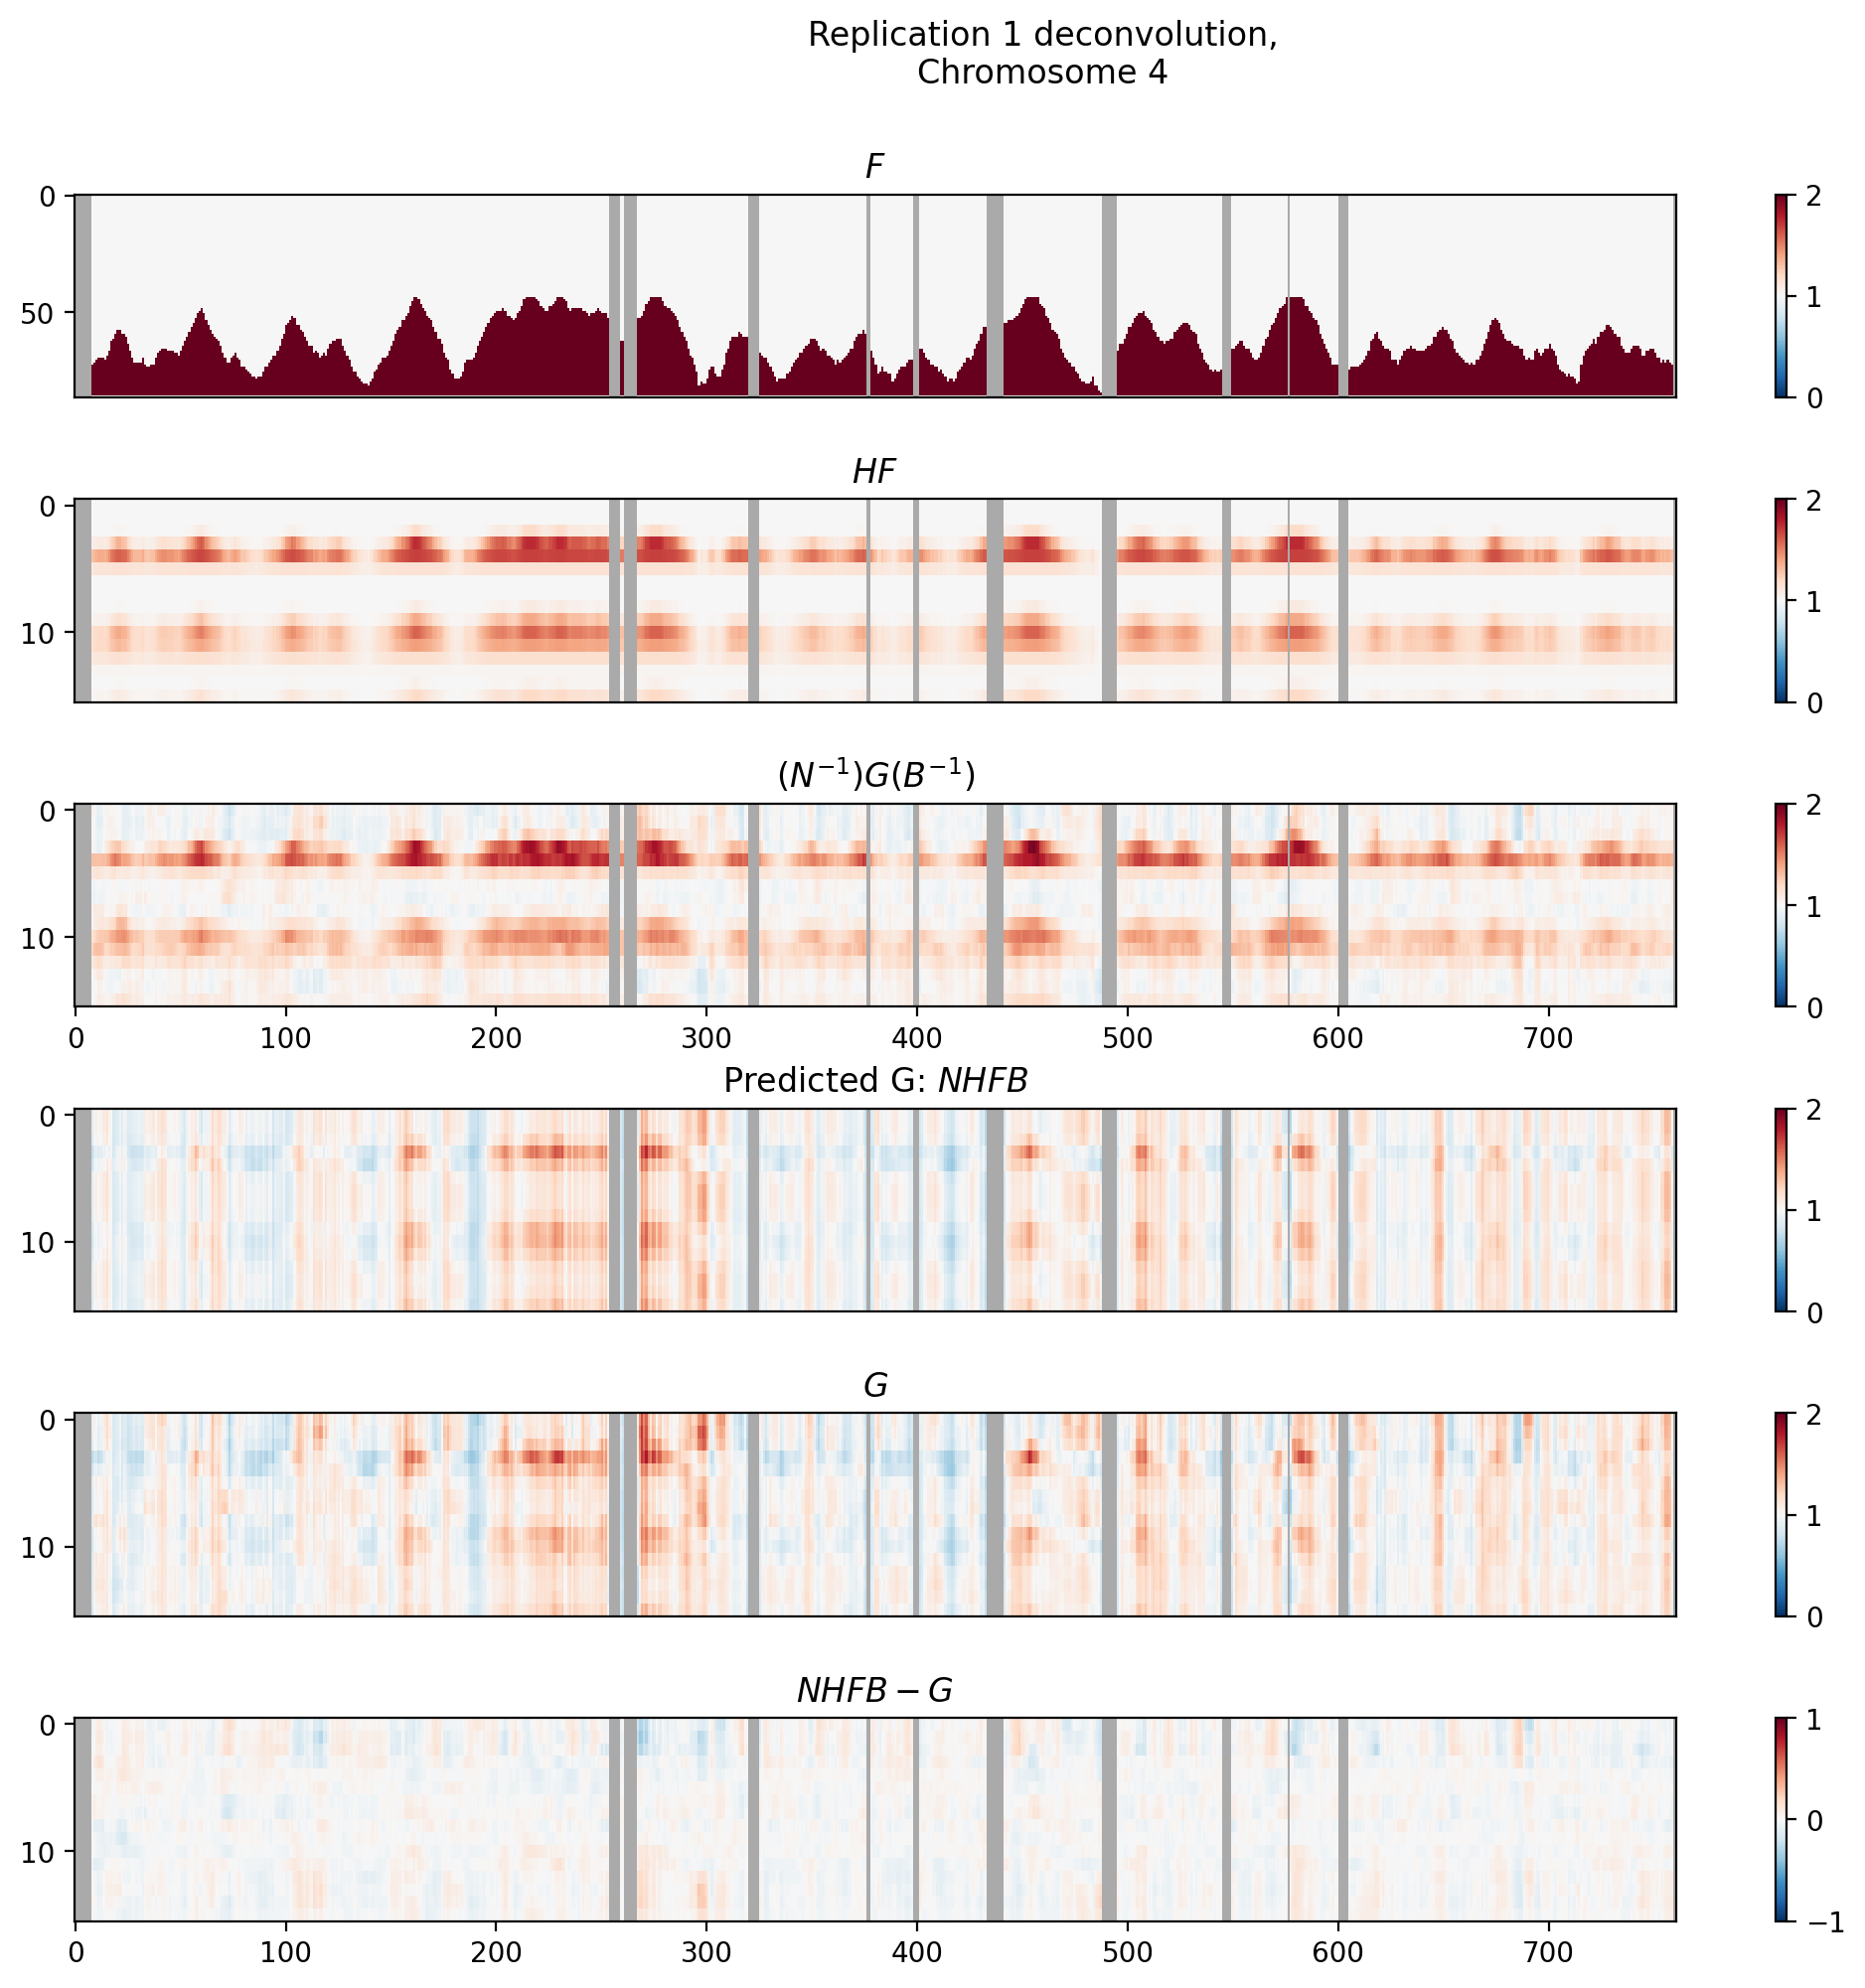

In [19]:
real_deconv1.plot_heatmaps()

In [20]:
optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv1.N,
    F=real_deconv1.F,
    B=real_deconv1.B,
    G=real_deconv1.G
)


In [21]:
from src.timer import Timer

timer = Timer()

num_epochs = 1000
num_iterations_N_B = 5
update_params_df = pd.DataFrame()

N = real_deconv1.N
B = real_deconv1.B

optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv1.N,
    F=real_deconv1.F,
    B=real_deconv1.B,
    G=real_deconv1.G
)

for epoch in range(num_epochs):
    print("Epoch: ", epoch)
    
    optimizer.optimize(maxiter=1000, verbose=True)

    real_deconv1.H = optimizer.current_H
        
    real_deconv1.iterative_deconvolution_updates(
        total_iterations=num_iterations_N_B, timer=timer,
        initial_B=B, initial_N=N)
    timer.print_time()
    
    params_row = pd.DataFrame([optimizer.params_df['value']], index=[epoch])
    params_row['opt_H_loss'] = optimizer.rn
    params_row['F_rn'] = real_deconv1.rn

    update_params_df = pd.concat([update_params_df, params_row])
    
    optimizer.N = real_deconv1.N
    optimizer.B = real_deconv1.B
    optimizer.F = real_deconv1.F
    
    N = real_deconv1.N
    B = real_deconv1.B

    print(update_params_df.iloc[-1])


Epoch:  0
Optimization [1]: Current loss: 0.0498791894182153
Optimization [101]: Current loss: 0.017752614026309444
Optimization [201]: Current loss: 0.015630627312080505
Optimization [301]: Current loss: 0.007623300656246909
Optimization [401]: Current loss: 0.007168938575632971
Optimization [501]: Current loss: 0.004317993489270494
Optimization [601]: Current loss: 0.003006801581801689
Optimization [701]: Current loss: 0.002639741574709724
Optimization terminated successfully.
         Current function value: 0.002640
         Iterations: 535
         Function evaluations: 766
Iteration 0
0/705 - 00:03:25.391
100/705 - 00:03:25.490
200/705 - 00:03:25.570
300/705 - 00:03:25.652
400/705 - 00:03:25.732
500/705 - 00:03:25.812
600/705 - 00:03:25.890
700/705 - 00:03:25.968
Iteration completed 00:03:26.899, rn=0.0026388978587162026
Iteration 1
0/705 - 00:03:26.903
100/705 - 00:03:26.988
200/705 - 00:03:27.072
300/705 - 00:03:27.151
400/705 - 00:03:27.230
500/705 - 00:03:27.309
600/705 - 00:

700/705 - 00:05:52.363
Iteration completed 00:05:53.243, rn=0.002619177469400578
Iteration 2
0/705 - 00:05:53.244
100/705 - 00:05:53.328
200/705 - 00:05:53.408
300/705 - 00:05:53.486
400/705 - 00:05:53.565
500/705 - 00:05:53.645
600/705 - 00:05:53.723
700/705 - 00:05:53.802
Iteration completed 00:05:54.623, rn=0.0026191337525393547
Iteration 3
0/705 - 00:05:54.624
100/705 - 00:05:54.703
200/705 - 00:05:54.782
300/705 - 00:05:54.861
400/705 - 00:05:54.941
500/705 - 00:05:55.021
600/705 - 00:05:55.100
700/705 - 00:05:55.179
Iteration completed 00:05:55.781, rn=0.0026191353606366064
Iteration 4
0/705 - 00:05:55.782
100/705 - 00:05:55.860
200/705 - 00:05:55.939
300/705 - 00:05:56.019
400/705 - 00:05:56.100
500/705 - 00:05:56.180
600/705 - 00:05:56.259
700/705 - 00:05:56.339
Iteration completed 00:05:56.998, rn=0.0026191353607241123
00:05:56.999
mu0           14.504369
lambda        60.000000
delta         15.092998
sigma0         6.330155
sigmav         0.024337
gamma1         0.660041
gam

Optimization [1]: Current loss: 0.0026204393168826837
Optimization [101]: Current loss: 0.0026203458055310594
Optimization terminated successfully.
         Current function value: 0.002620
         Iterations: 67
         Function evaluations: 124
Iteration 0
0/705 - 00:08:52.499
100/705 - 00:08:52.579
200/705 - 00:08:52.678
300/705 - 00:08:52.757
400/705 - 00:08:52.836
500/705 - 00:08:52.914
600/705 - 00:08:52.993
700/705 - 00:08:53.072
Iteration completed 00:08:53.901, rn=0.0026203290798303943
Iteration 1
0/705 - 00:08:53.902
100/705 - 00:08:53.980
200/705 - 00:08:54.059
300/705 - 00:08:54.138
400/705 - 00:08:54.218
500/705 - 00:08:54.297
600/705 - 00:08:54.376
700/705 - 00:08:54.455
Iteration completed 00:08:54.687, rn=0.0026206742672972632
Iteration 2
0/705 - 00:08:54.688
100/705 - 00:08:54.769
200/705 - 00:08:54.848
300/705 - 00:08:54.928
400/705 - 00:08:55.007
500/705 - 00:08:55.086
600/705 - 00:08:55.165
700/705 - 00:08:55.244
Iteration completed 00:08:55.974, rn=0.002620570690

500/705 - 00:11:28.344
600/705 - 00:11:28.421
700/705 - 00:11:28.499
Iteration completed 00:11:29.406, rn=0.002621040931937985
Iteration 4
0/705 - 00:11:29.408
100/705 - 00:11:29.492
200/705 - 00:11:29.573
300/705 - 00:11:29.657
400/705 - 00:11:29.739
500/705 - 00:11:29.818
600/705 - 00:11:29.897
700/705 - 00:11:29.976
Iteration completed 00:11:30.458, rn=0.0026209990267250173
00:11:30.459
mu0           14.709434
lambda        60.000000
delta         15.152830
sigma0         6.289734
sigmav         0.029048
gamma1         0.659627
gamma2         1.000000
halted         0.000004
opt_H_loss     0.002621
F_rn           0.002621
Name: 13, dtype: float64
Epoch:  14
Optimization [1]: Current loss: 0.0026209990267250173
Optimization [101]: Current loss: 0.0026210002199333463
Optimization terminated successfully.
         Current function value: 0.002621
         Iterations: 55
         Function evaluations: 102
Iteration 0
0/705 - 00:11:54.500
100/705 - 00:11:54.579
200/705 - 00:11:54.658
300

200/705 - 00:13:50.807
300/705 - 00:13:50.886
400/705 - 00:13:50.966
500/705 - 00:13:51.046
600/705 - 00:13:51.125
700/705 - 00:13:51.204
Iteration completed 00:13:51.968, rn=0.002621758356649634
Iteration 2
0/705 - 00:13:51.971
100/705 - 00:13:52.050
200/705 - 00:13:52.130
300/705 - 00:13:52.209
400/705 - 00:13:52.289
500/705 - 00:13:52.368
600/705 - 00:13:52.447
700/705 - 00:13:52.526
Iteration completed 00:13:53.404, rn=0.0026217589544838917
Iteration 3
0/705 - 00:13:53.405
100/705 - 00:13:53.484
200/705 - 00:13:53.564
300/705 - 00:13:53.643
400/705 - 00:13:53.722
500/705 - 00:13:53.801
600/705 - 00:13:53.880
700/705 - 00:13:53.958
Iteration completed 00:13:54.631, rn=0.002621758954507228
Iteration 4
0/705 - 00:13:54.633
100/705 - 00:13:54.712
200/705 - 00:13:54.791
300/705 - 00:13:54.871
400/705 - 00:13:54.949
500/705 - 00:13:55.029
600/705 - 00:13:55.110
700/705 - 00:13:55.192
Iteration completed 00:13:55.932, rn=0.002621758954507228
00:13:55.932
mu0           14.746241
lambda    

...

Optimization [1]: Current loss: 0.002622682712283994
Optimization terminated successfully.
         Current function value: 0.002623
         Iterations: 47
         Function evaluations: 91
Iteration 0
0/705 - 06:59:56.700
100/705 - 06:59:56.780
200/705 - 06:59:56.860
300/705 - 06:59:56.940
400/705 - 06:59:57.018
500/705 - 06:59:57.097
600/705 - 06:59:57.176
700/705 - 06:59:57.254
Iteration completed 06:59:57.630, rn=0.0026226845193336925
Iteration 1
0/705 - 06:59:57.631
100/705 - 06:59:57.709
200/705 - 06:59:57.788
300/705 - 06:59:57.867
400/705 - 06:59:57.946
500/705 - 06:59:58.024
600/705 - 06:59:58.102
700/705 - 06:59:58.181
Iteration completed 06:59:58.507, rn=0.00262271448461461
Iteration 2
0/705 - 06:59:58.508
100/705 - 06:59:58.587
200/705 - 06:59:58.670
300/705 - 06:59:58.749
400/705 - 06:59:58.829
500/705 - 06:59:58.906
600/705 - 06:59:58.984
700/705 - 06:59:59.074
Iteration completed 06:59:59.438, rn=0.0026227137583599075
Iteration 3
0/705 - 06:59:59.440
100/705 - 06:59:59.

100/705 - 07:01:37.497
200/705 - 07:01:37.576
300/705 - 07:01:37.655
400/705 - 07:01:37.734
500/705 - 07:01:37.812
600/705 - 07:01:37.890
700/705 - 07:01:37.969
Iteration completed 07:01:38.215, rn=0.0026227237549876483
07:01:38.215
mu0           14.924174
lambda        60.000000
delta         15.129913
sigma0         6.291898
sigmav         0.028973
gamma1         0.663428
gamma2         1.000000
halted         0.000058
opt_H_loss     0.002623
F_rn           0.002623
Name: 984, dtype: float64
Epoch:  985
Optimization [1]: Current loss: 0.002622723754987649
Optimization terminated successfully.
         Current function value: 0.002623
         Iterations: 46
         Function evaluations: 90
Iteration 0
0/705 - 07:01:58.262
100/705 - 07:01:58.345
200/705 - 07:01:58.424
300/705 - 07:01:58.504
400/705 - 07:01:58.582
500/705 - 07:01:58.665
600/705 - 07:01:58.746
700/705 - 07:01:58.826
Iteration completed 07:01:59.055, rn=0.0026227255991181056
Iteration 1
0/705 - 07:01:59.057
100/705 - 07

100/705 - 07:03:39.157
200/705 - 07:03:39.236
300/705 - 07:03:39.321
400/705 - 07:03:39.406
500/705 - 07:03:39.485
600/705 - 07:03:39.566
700/705 - 07:03:39.646
Iteration completed 07:03:40.116, rn=0.0026227755240705287
Iteration 3
0/705 - 07:03:40.119
100/705 - 07:03:40.199
200/705 - 07:03:40.279
300/705 - 07:03:40.360
400/705 - 07:03:40.440
500/705 - 07:03:40.518
600/705 - 07:03:40.596
700/705 - 07:03:40.674
Iteration completed 07:03:41.213, rn=0.002622775524039214
Iteration 4
0/705 - 07:03:41.215
100/705 - 07:03:41.294
200/705 - 07:03:41.372
300/705 - 07:03:41.452
400/705 - 07:03:41.530
500/705 - 07:03:41.609
600/705 - 07:03:41.687
700/705 - 07:03:41.767
Iteration completed 07:03:42.228, rn=0.002622775524039213
07:03:42.228
mu0           14.920464
lambda        60.000000
delta         15.143321
sigma0         6.292722
sigmav         0.028871
gamma1         0.663248
gamma2         1.000000
halted         0.000063
opt_H_loss     0.002623
F_rn           0.002623
Name: 989, dtype: float

100/705 - 07:05:40.086
200/705 - 07:05:40.165
300/705 - 07:05:40.245
400/705 - 07:05:40.323
500/705 - 07:05:40.405
600/705 - 07:05:40.483
700/705 - 07:05:40.562
Iteration completed 07:05:40.969, rn=0.0026227564102333932
Iteration 1
0/705 - 07:05:40.971
100/705 - 07:05:41.050
200/705 - 07:05:41.130
300/705 - 07:05:41.209
400/705 - 07:05:41.289
500/705 - 07:05:41.367
600/705 - 07:05:41.447
700/705 - 07:05:41.525
Iteration completed 07:05:41.748, rn=0.002622837621877602
Iteration 2
0/705 - 07:05:41.750
100/705 - 07:05:41.829
200/705 - 07:05:41.909
300/705 - 07:05:41.988
400/705 - 07:05:42.067
500/705 - 07:05:42.146
600/705 - 07:05:42.224
700/705 - 07:05:42.303
Iteration completed 07:05:42.580, rn=0.0026228402928575338
Iteration 3
0/705 - 07:05:42.581
100/705 - 07:05:42.660
200/705 - 07:05:42.739
300/705 - 07:05:42.818
400/705 - 07:05:42.905
500/705 - 07:05:42.984
600/705 - 07:05:43.068
700/705 - 07:05:43.147
Iteration completed 07:05:43.407, rn=0.00262284029298674
Iteration 4
0/705 - 07:0

mu0           14.928321
lambda        60.000000
delta         15.138800
sigma0         6.287275
sigmav         0.028934
gamma1         0.663543
gamma2         1.000000
halted         0.000073
opt_H_loss     0.002623
F_rn           0.002623
Name: 998, dtype: float64
Epoch:  999
Optimization [1]: Current loss: 0.002622800278076236
Optimization terminated successfully.
         Current function value: 0.002623
         Iterations: 40
         Function evaluations: 81
Iteration 0
0/705 - 07:07:39.465
100/705 - 07:07:39.557
200/705 - 07:07:39.639
300/705 - 07:07:39.718
400/705 - 07:07:39.796
500/705 - 07:07:39.874
600/705 - 07:07:39.952
700/705 - 07:07:40.031
Iteration completed 07:07:40.522, rn=0.0026228026300931673
Iteration 1
0/705 - 07:07:40.523
100/705 - 07:07:40.603
200/705 - 07:07:40.682
300/705 - 07:07:40.761
400/705 - 07:07:40.840
500/705 - 07:07:40.918
600/705 - 07:07:40.997
700/705 - 07:07:41.076
Iteration completed 07:07:41.394, rn=0.0026228199571182334
Iteration 2
0/705 - 07:07

Text(0.5, 0.98, 'Cell cycle parameter updates, 1000 epochs')

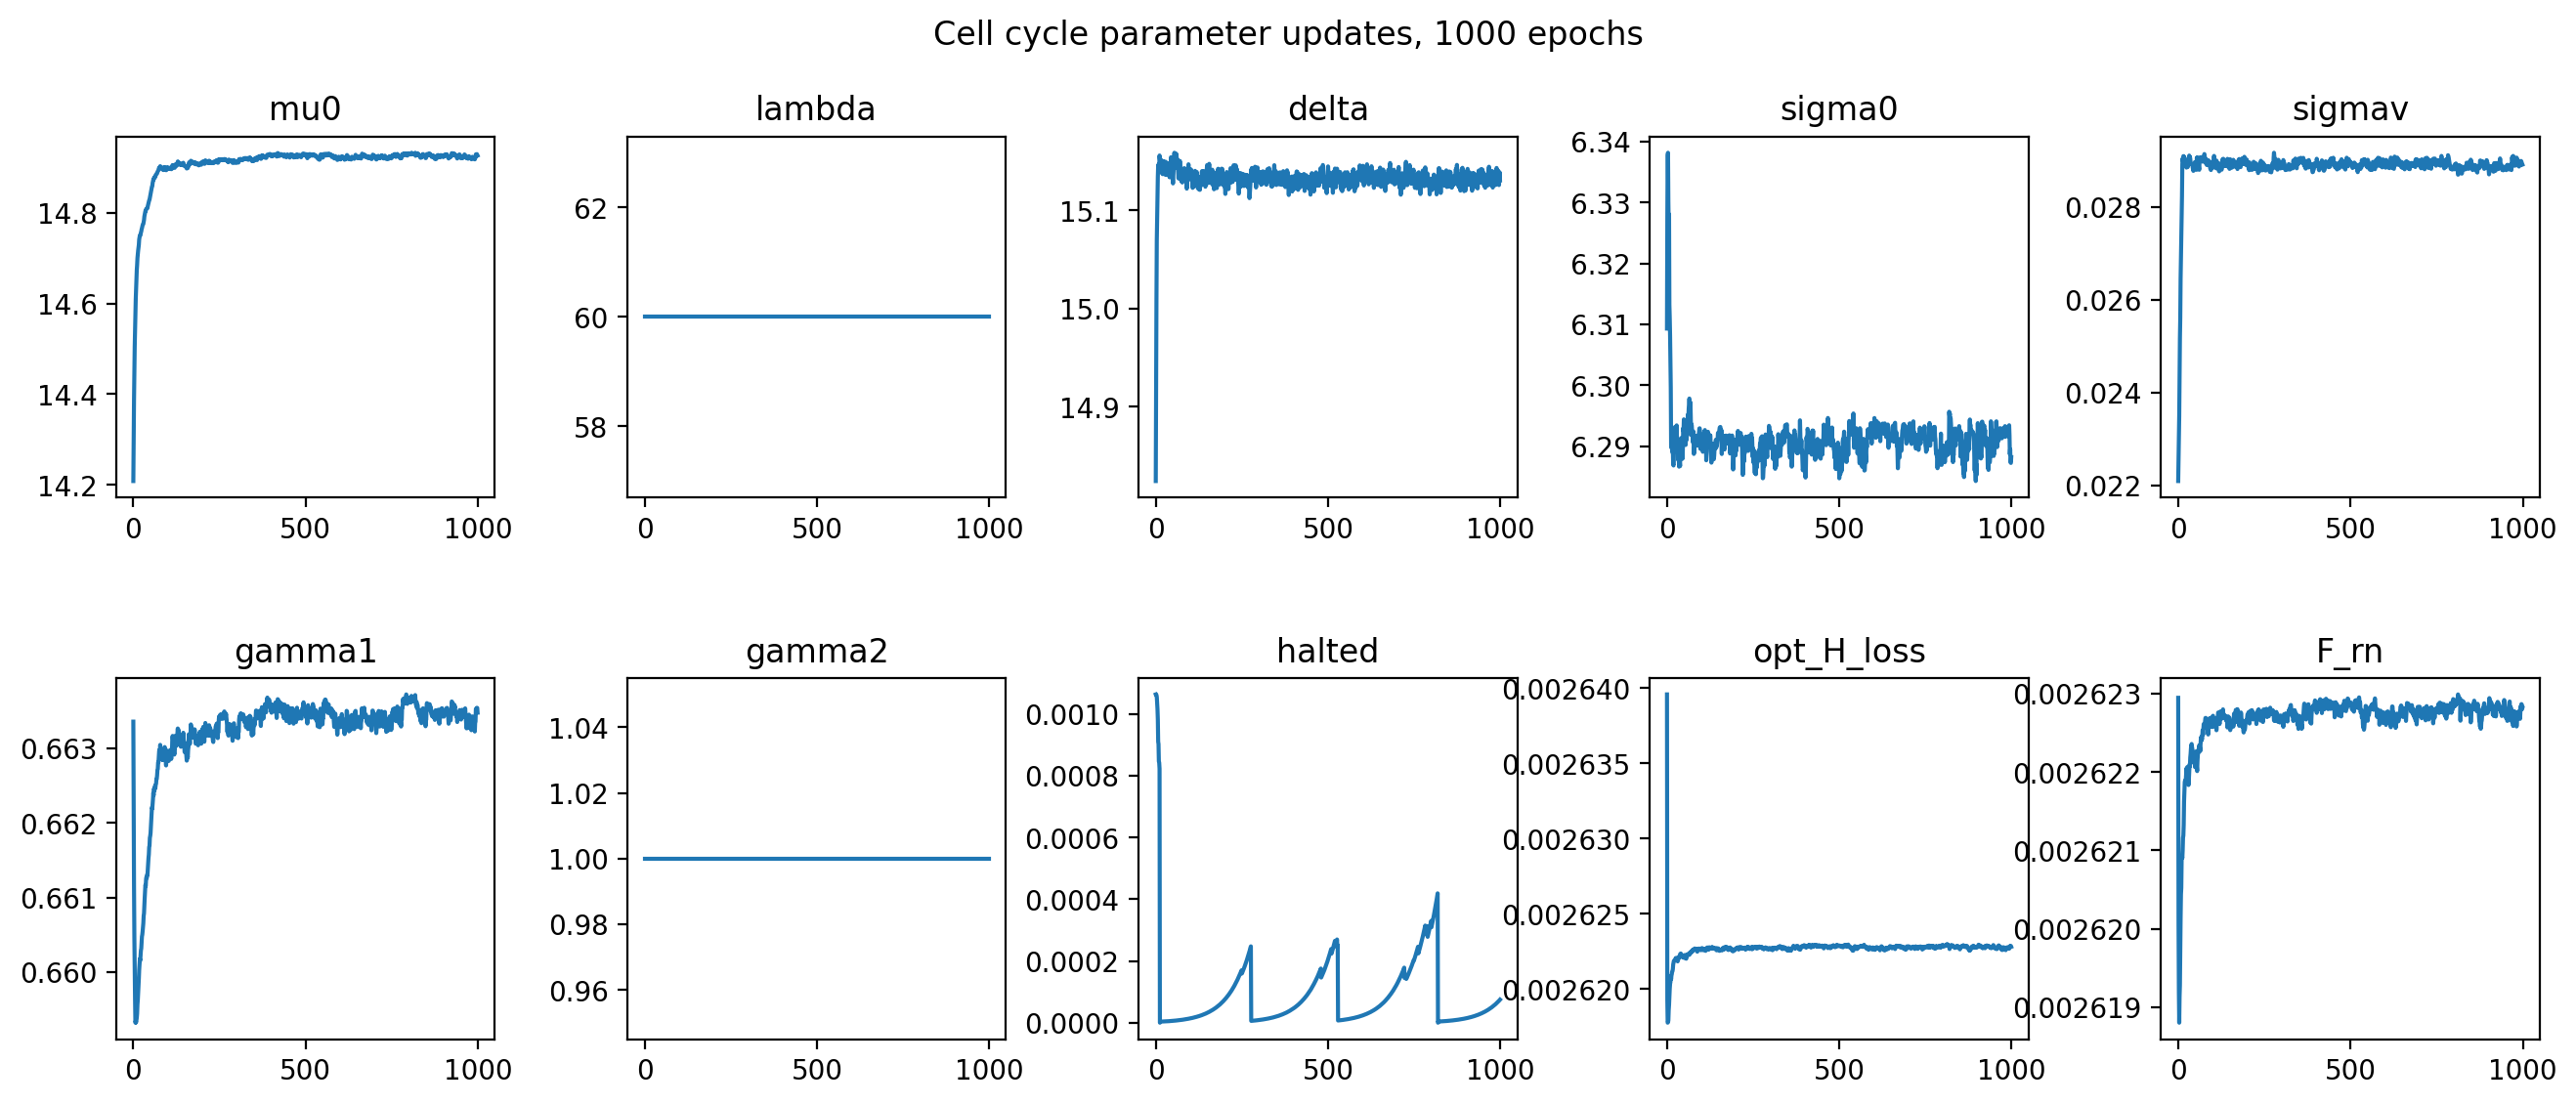

In [22]:
r, c = 2, 5

plt.figure(figsize=(16, 6))

for i, param in enumerate(update_params_df.columns):
        
    plt.subplot(r, c, i+1)
    plt.plot(update_params_df[param])
    plt.title(param)
    
plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.suptitle(f"Cell cycle parameter updates, {num_epochs} epochs")

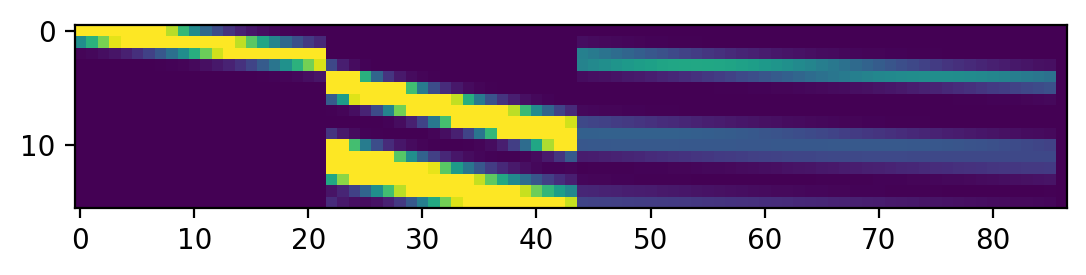

In [23]:
plt.imshow(real_deconv1.H, vmax=0.05)

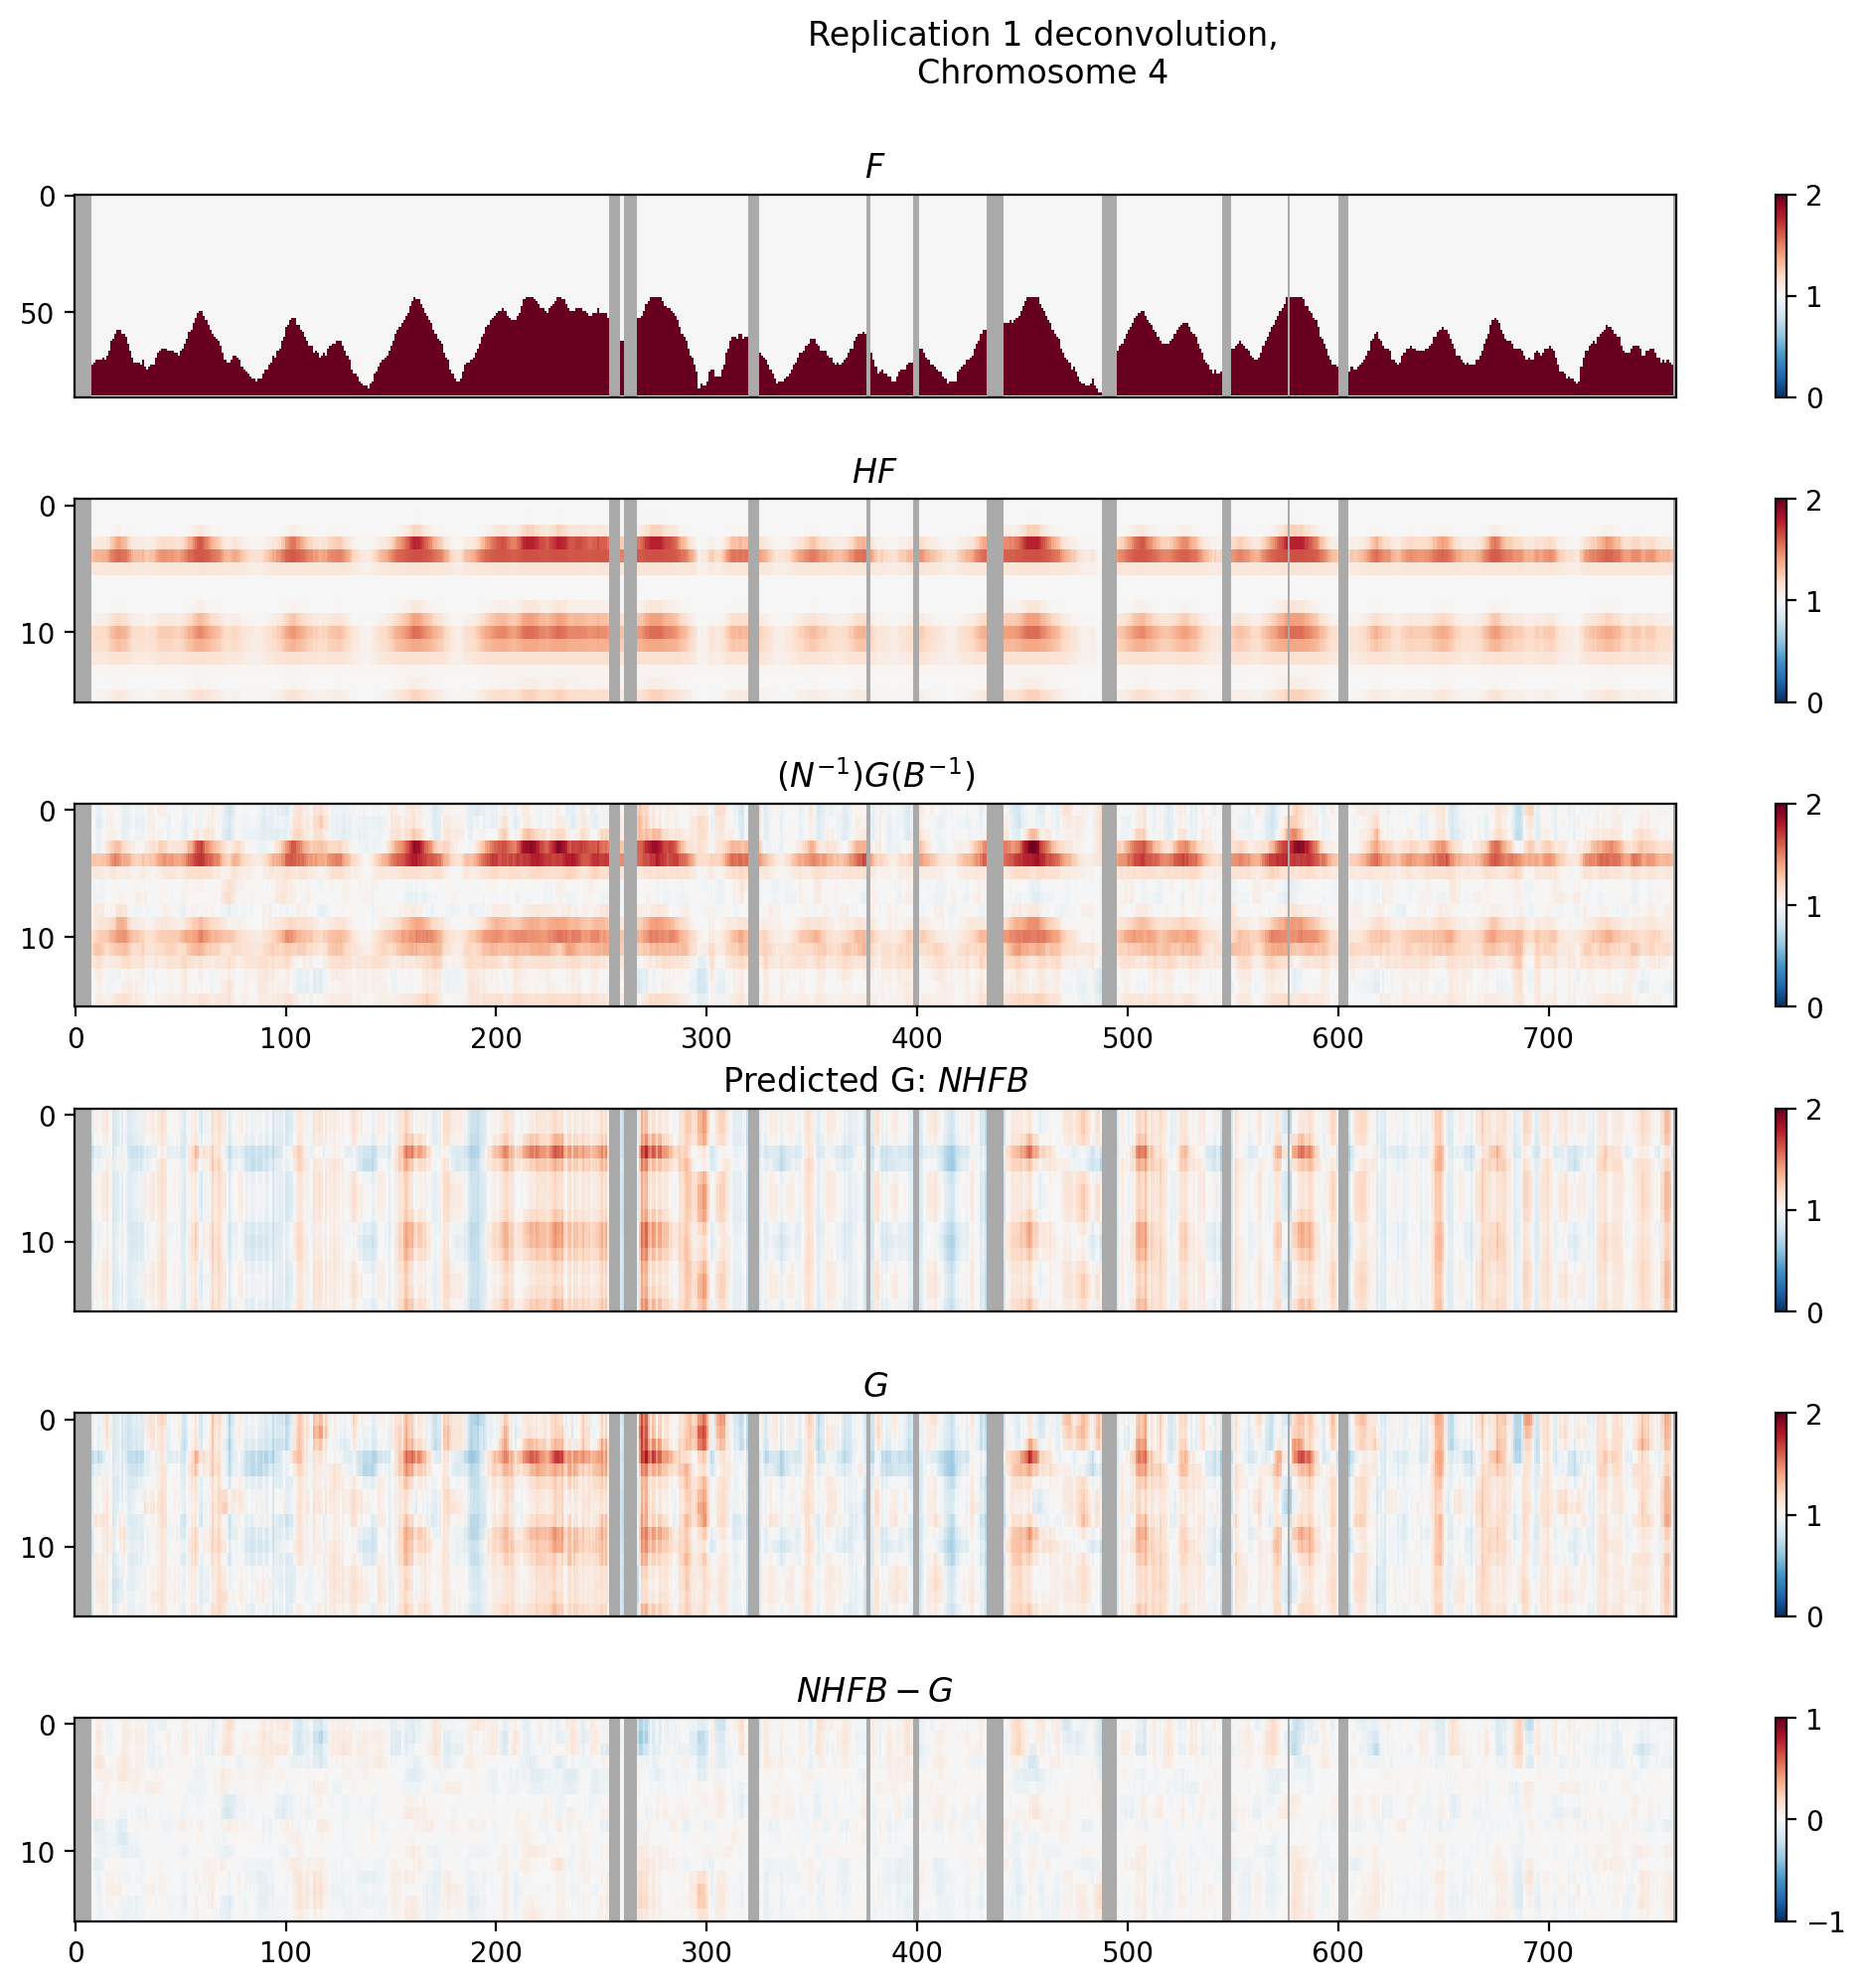

In [24]:
real_deconv1.plot_heatmaps()

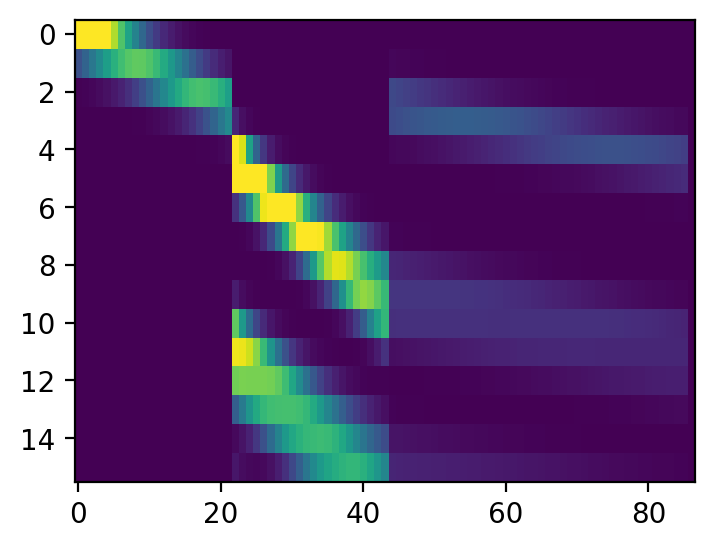

In [25]:
fig = plt.figure(figsize=(4, 3))
plt.imshow(config.H, vmax=0.1, aspect='auto', interpolation='none')

In [41]:
real_deconv1.iterative_deconvolution_updates(20)

Iteration 0
0/705 - 00:00:00.009
100/705 - 00:00:00.090
200/705 - 00:00:00.168
300/705 - 00:00:00.248
400/705 - 00:00:00.327
500/705 - 00:00:00.406
600/705 - 00:00:00.485
700/705 - 00:00:00.564
Iteration completed 00:00:00.936, rn=0.006469148054299935
Iteration 1
0/705 - 00:00:00.937
100/705 - 00:00:01.024
200/705 - 00:00:01.121
300/705 - 00:00:01.202
400/705 - 00:00:01.280
500/705 - 00:00:01.359
600/705 - 00:00:01.438
700/705 - 00:00:01.520
Iteration completed 00:00:01.883, rn=0.003489268199819781
Iteration 2
0/705 - 00:00:01.885
100/705 - 00:00:01.968
200/705 - 00:00:02.048
300/705 - 00:00:02.126
400/705 - 00:00:02.204
500/705 - 00:00:02.280
600/705 - 00:00:02.359
700/705 - 00:00:02.452
Iteration completed 00:00:02.702, rn=0.0029242658278082114
Iteration 3
0/705 - 00:00:02.704
100/705 - 00:00:02.799
200/705 - 00:00:02.878
300/705 - 00:00:02.959
400/705 - 00:00:03.039
500/705 - 00:00:03.119
600/705 - 00:00:03.197
700/705 - 00:00:03.286
Iteration completed 00:00:03.389, rn=0.0027846882

In [43]:
config.params_dic

{'mu0': 14.926855997420141,
 'delta': 15.130663943754426,
 'sigma0': 6.288228436658738,
 'sigmav': 0.028913623544450304,
 'lambda': 60.0,
 'gamma1': 0.6634792366157173,
 'gamma2': 1.0,
 'halted': 7.473645129759716e-05,
 'alpha': 22,
 'opt_H_loss': 0.002622800278076236,
 'F_rn': 0.002622818840326054}

3.3652076338428287

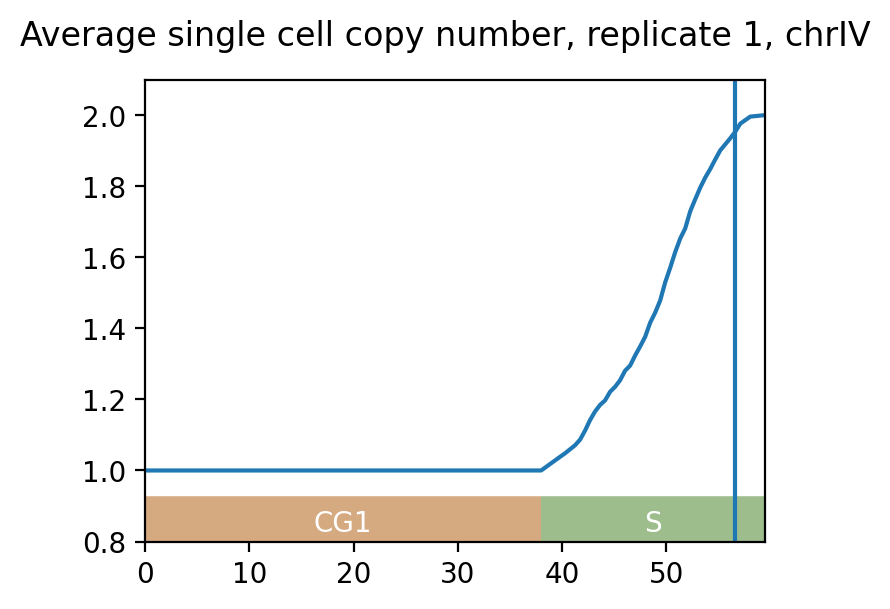

In [53]:
from src.chromatin_model import draw_phase_label_annotations
config = real_deconv1.config

fig = plt.figure(figsize=(4, 3))
t_indices = config.get_Hpositions_for_branch('t')
t_tps = config.get_timepoints_for_branch('t')
plt.plot(t_tps, real_deconv1.F.mean(axis=1)[t_indices])
draw_phase_label_annotations(plt.gca(), config, flip=True, annotations_x=0.85)
plt.xlim(t_tps[0], t_tps[-1])
plt.ylim(0.8, 2.1)
plt.suptitle("Average single cell copy number, replicate 1, chrIV")

# Plot when 95% of the genome has been replicated
x, y = t_tps, real_deconv1.F.mean(axis=1)[t_indices]
g2m_start = t_tps[y > 1.95][0]
plt.axvline(g2m_start)
config.params_dic['lambda'] - g2m_start